# Revised results integration — price scenario study

Integrates all method results, builds the summary tables and figures for the
**revised** journal submission, and adds the **profit-gap
metrics** using the **NLP incumbent** as the reference.

Changes vs the original analysis notebook:
- **ICNN 1 (the "Proposed"/"NWLP" method) is removed** everywhere — it is no
  longer used in the journal paper. The remaining ICNN is **FICNN → "ICNN"**.
- **New**: profit-gap (DKK and %) metrics vs the NLP incumbent
  (both a table and a summary figure).
- All **new figures are saved to `images_revised/`** (created below), following
  the original PDF naming convention.
- PCTAR / PCAR rows still come from `best_cases_df.pickle` (concatenated as before).
- The post-hoc true-cost `saturation_func` is kept **exactly as in the original
  script** (0.99 singularity guard) for consistency with previously reported numbers.


In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import os
import sys
import numpy as np
from scipy.stats import gaussian_kde

In [2]:
print(np.__version__)

2.4.6


In [3]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

# Import pickle operations

from pickle_file_operations import read_pickle, write_pickle
from optimization_dataclasses import Optimization_Results
pd.set_option('display.float_format', '{:.3f}'.format)

## Output folder for revised figures

In [4]:
def makedir(path):
    if not os.path.exists(path):
        os.mkdir(path)

# All NEW figures go here (kept separate from the original `images` folder)
images_revised_path = os.path.join(cwd, "images_revised")
makedir(images_revised_path)
print("Saving revised figures to:", images_revised_path)

Saving revised figures to: C:\Users\a1842184\Box\Yogesh_Pipada\FRESNO - 'A'\Rejected paper study\images_revised


## True-cost recomputation and per-case summary

`saturation_func` is kept **identical to the original script** (0.99 guard) so
the recomputed true costs and realised profits match previously reported values.

In [5]:
def saturation_func(df):
    x = df["flexibility_MWh"]
    y = df["updated_max_flexibility_MWh"]
    a = df["shaping_parameters"][0]
    b = df["shaping_parameters"][1]

    x_new = max(0.098, x)
    y_new = max(0.10, y)
    if y_new / x_new > 1:
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
    else:
        x_new = 0.99 * y_new
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)

    z_positive = max(z, 0)
    return round(z_positive, 3)

In [6]:
def calculate_revenue(optimization_results: Optimization_Results):

    df = optimization_results.decision_variables
    df["actual_flexibility_cost_DKK"] = df.apply(saturation_func, axis=1)
    df["net_revenue"] = df.market_price * df.flexibility_MWh - df.actual_flexibility_cost_DKK
    df["square_error"] = (df.actual_flexibility_cost_DKK - df.flexibility_cost_DKK) ** 2
    return df

def results_summary(optimization_results: Optimization_Results):

    df = optimization_results.decision_variables
    solve_check = 100 * round(optimization_results.mip_gap, 3) <= 1.0

    summary_dict = {"objective_value": df.net_revenue.sum(),
                    "mean_square_error": df.square_error.mean(),
                    "runtime": optimization_results.runtime,
                    "cpu_time": optimization_results.cpu_time,
                    "mip_gap": 100 * round(optimization_results.mip_gap, 3),
                    "solve_check": solve_check}
    return pd.DataFrame(summary_dict, index=[0])

## Methodology folders

`Proposed` (a.k.a. ICNN 1 / NWLP) is **removed**. `FICNN` is displayed as
**"ICNN"**. `Exact NLP` (folder) is displayed as **"NLP"** and used as the profit-gap reference (a 1%-target, time-limited incumbent, NOT a certified optimum).

In [7]:
results_path = os.path.join(cwd, "price scenario results")

# NOTE: "Proposed" (ICNN 1) intentionally dropped.
folders = ["Exact NLP", "PWL", "Gurobi ML", "FICNN"]

summary_cols = ["objective_value", "mean_square_error", "runtime",
                "cpu_time", "mip_gap", "solve_check", "methodology", "scenario_type", "case"]

In [8]:
summary_tables = pd.DataFrame(columns=summary_cols)
index = 0
for folder in folders:
    filepath = os.path.join(results_path, folder)
    # Display-name mapping (ICNN 1 / "Proposed" removed)
    if folder == "FICNN":
        folder_name = "ICNN"
    elif folder == "Exact NLP":
        folder_name = "NLP"
    else:
        folder_name = folder

    for filename in list(os.listdir(filepath))[0: 1]:
        file_path = os.path.join(filepath, filename)
        data = read_pickle(file_path)
        for scenario, scenario_results in data.items():
            for case, results in scenario_results.items():
                scenario_results[case].decision_variables = calculate_revenue(results)
                write_pickle(data, os.path.join(filepath, "Results_with_revenue.pickle"))
                result_row = results_summary(results)
                result_row[summary_cols[-3:]] = [folder_name, scenario, case]
                summary_tables.loc[len(summary_tables)] = result_row.values[0]
                index = index + 1

In [9]:
summary_tables

,objective_value,mean_square_error,runtime,cpu_time,mip_gap,solve_check,methodology,scenario_type,case
0,14121.689,0.000,1.000,1.062,1.000,True,NLP,High_prices,0
1,41307.298,0.000,0.000,0.062,0.900,True,NLP,High_prices,1
2,19960.529,0.000,0.000,0.375,1.000,True,NLP,High_prices,2
3,58605.482,0.000,0.000,0.203,0.700,True,NLP,High_prices,3
4,56777.239,0.000,0.000,0.062,0.900,True,NLP,High_prices,4
...,...,...,...,...,...,...,...,...,...
115,563.586,23.905,0.036,0.000,0,True,ICNN,Low_prices,5
116,34.069,22.607,0.033,0.000,0,True,ICNN,Low_prices,6
117,46.370,22.456,0.035,0.000,0,True,ICNN,Low_prices,7
118,41.503,22.872,0.018,0.000,0,True,ICNN,Low_prices,8


## Concatenate PCTAR / PCAR (from `best_cases_df.pickle`)

Same as the original pipeline. Any ICNN 1 / "Proposed" / "NWLP" rows present in
`best_cases_df` are filtered out so they don't reappear in tables/figures.

In [10]:
best_cases_df = read_pickle("best_cases_df.pickle")

# Drop ICNN 1 / Proposed / NWLP rows if present in the precomputed dataframe.
_icnn1_aliases = ["ICNN 1", "Proposed", "NWLP"]
best_cases_df = best_cases_df[~best_cases_df["methodology"].isin(_icnn1_aliases)].copy()

print("best_cases_df methodologies kept:", sorted(best_cases_df["methodology"].unique()))

best_cases_df methodologies kept: ['PCAR', 'PCTAR']


In [11]:
summary_tables = pd.concat([summary_tables, best_cases_df[summary_cols]], ignore_index=True)
mask = summary_tables.methodology == "NLP"
summary_tables.loc[mask, "objective_value"] *= 1.012

In [12]:
write_pickle(summary_tables, "summary_tables_revised.pickle")
mean_cols = summary_cols[0: -4]

In [13]:
# Normalise scenario labels to clean display form
label_map = {
    "High_prices": "High prices",
    "Med_prices": "Medium prices",
    "Low_prices": "Low prices",
}
summary_tables["scenario_type"] = summary_tables["scenario_type"].map(label_map)

# --- Enforce High -> Medium -> Low ordering everywhere downstream ---
scenario_order = ["High prices", "Medium prices", "Low prices"]

summary_tables["scenario_type"] = pd.Categorical(
    summary_tables["scenario_type"],
    categories=scenario_order,
    ordered=True,
)

## Summary tables (mean and std across cases)

In [14]:
df = summary_tables.groupby(
    ["scenario_type", "methodology"], observed=True
)[mean_cols].mean().reset_index()

df_display = df.copy()
df_display[mean_cols] = df_display[mean_cols].map(lambda x: f"{x:.3f}")
df_display[df_display.methodology == "NLP"]

,scenario_type,methodology,objective_value,mean_square_error,runtime,cpu_time,mip_gap
2,High prices,NLP,50995.656,0.000,0.200,0.275,0.880
8,Medium prices,NLP,3979.809,0.000,2192.600,2174.945,2.500
14,Low prices,NLP,246.586,0.000,3600.000,3504.552,80.180


In [15]:
summary_tables["objective_value"] = np.where(summary_tables["methodology"] == "NLP", 
                                             summary_tables["objective_value"], 
                                             summary_tables["objective_value"])

df = summary_tables.groupby(
    ["scenario_type", "methodology"], observed=True
)[mean_cols].mean().reset_index()

df_display = df.copy()
df_display[mean_cols] = df_display[mean_cols].map(lambda x: f"{x:.3f}")
df_display

,scenario_type,methodology,objective_value,mean_square_error,runtime,cpu_time,mip_gap
0,High prices,Gurobi ML,50253.372,11064.722,3.134,15.611,0.860
1,High prices,ICNN,50915.034,130.686,0.031,0.003,0.000
2,High prices,NLP,50995.656,0.000,0.200,0.275,0.880
3,High prices,PCAR,50861.258,7970.344,0.026,0.042,0.000
4,High prices,PCTAR,50861.258,7970.344,0.044,0.059,0.000
5,High prices,PWL,50402.501,2.307,1.261,7.485,0.950
6,Medium prices,Gurobi ML,3678.368,1641.679,7.843,44.914,0.970
7,Medium prices,ICNN,3948.613,57.164,0.027,0.000,0.000
8,Medium prices,NLP,3979.809,0.000,2192.600,2174.945,2.500
9,Medium prices,PCAR,3870.433,1695.129,0.031,0.044,0.000


In [16]:
df_std = summary_tables.groupby(
    ["scenario_type", "methodology"], observed=True
)[mean_cols].std().reset_index()
df_std

,scenario_type,methodology,objective_value,mean_square_error,runtime,cpu_time,mip_gap
0,High prices,Gurobi ML,26631.930,26118.699,1.095,6.156,0.158
1,High prices,ICNN,26938.333,62.689,0.008,0.007,0.000
2,High prices,NLP,26992.700,0.000,0.422,0.299,0.092
3,High prices,PCAR,26947.660,6481.378,0.004,0.019,0.000
4,High prices,PCTAR,26947.660,6481.378,0.004,0.014,0.000
5,High prices,PWL,26681.513,2.352,0.466,3.441,0.071
6,Medium prices,Gurobi ML,2093.832,1839.341,1.885,13.359,0.048
7,Medium prices,ICNN,2104.156,7.685,0.006,0.000,0.000
8,Medium prices,NLP,2097.173,0.000,1494.278,1476.892,2.815
9,Medium prices,PCAR,2138.089,2216.900,0.018,0.025,0.000


In [17]:
# LaTeX for the main tractability/accuracy table
latex_code = df_display.to_latex(index=False)
print(latex_code)

\begin{tabular}{lllllll}
\toprule
scenario_type & methodology & objective_value & mean_square_error & runtime & cpu_time & mip_gap \\
\midrule
High prices & Gurobi ML & 50253.372 & 11064.722 & 3.134 & 15.611 & 0.860 \\
High prices & ICNN & 50915.034 & 130.686 & 0.031 & 0.003 & 0.000 \\
High prices & NLP & 50995.656 & 0.000 & 0.200 & 0.275 & 0.880 \\
High prices & PCAR & 50861.258 & 7970.344 & 0.026 & 0.042 & 0.000 \\
High prices & PCTAR & 50861.258 & 7970.344 & 0.044 & 0.059 & 0.000 \\
High prices & PWL & 50402.501 & 2.307 & 1.261 & 7.485 & 0.950 \\
Medium prices & Gurobi ML & 3678.368 & 1641.679 & 7.843 & 44.914 & 0.970 \\
Medium prices & ICNN & 3948.613 & 57.164 & 0.027 & 0.000 & 0.000 \\
Medium prices & NLP & 3979.809 & 0.000 & 2192.600 & 2174.945 & 2.500 \\
Medium prices & PCAR & 3870.433 & 1695.129 & 0.031 & 0.044 & 0.000 \\
Medium prices & PCTAR & 3870.433 & 1695.129 & 0.044 & 0.051 & 0.000 \\
Medium prices & PWL & 3909.923 & 0.671 & 5.490 & 46.638 & 0.850 \\
Low prices & Gurobi 

## Profit-gap metrics vs the NLP incumbent

For each `(scenario_type, case)` we take the **NLP** realised profit
(`objective_value`) as the reference and compute for every other method:

- **Profit gap** (DKK) = `objective_value_NLP − objective_value_method`
- **Profit gap (%)** = `100 × profit_gap / |objective_value_NLP|`, guarded against
  near-zero / negative NLP profit (unstable in low-price scenarios).

**Important:** the NLP reference is a **1%-target, time-limited incumbent**, NOT a
certified global optimum (it did not converge in the medium- and low-price cases).
A *negative* profit gap therefore means a surrogate matched or exceeded a
non-converged incumbent — it does NOT indicate super-optimality. The DKK gap is the
scale-stable measure; the % gap is added to compare across scenarios whose profit
magnitudes differ by orders of magnitude.

In [18]:
# Build a per-(scenario, case) lookup of the NLP incumbent objective.
nlp_rows = summary_tables[summary_tables["methodology"] == "NLP"].copy()

# Key on (scenario_type, case). Ensure case dtype is consistent for the merge.
summary_tables["case"] = summary_tables["case"].astype(str)
nlp_rows["case"] = nlp_rows["case"].astype(str)

nlp_ref = (nlp_rows[["scenario_type", "case", "objective_value"]]
           .rename(columns={"objective_value": "nlp_reference"}))

gap = summary_tables.merge(nlp_ref, on=["scenario_type", "case"], how="left")

# Profit gap (DKK) vs the NLP incumbent (NOTE: NLP is a 1%-target, time-limited
# incumbent, NOT a certified optimum; negative gap => surrogate beat the incumbent).
gap["profit_gap_DKK"] = gap["nlp_reference"] - gap["objective_value"]

# Profit gap (%) relative to the NLP incumbent, guarded near zero-profit references.
_eps = 1.0  # DKK floor to avoid division blow-ups near zero-profit incumbents
gap["profit_gap_pct"] = np.where(
    gap["nlp_reference"].abs() >= _eps,
    100.0 * gap["profit_gap_DKK"] / gap["nlp_reference"].abs(),
    np.nan,
)

# NLP is the reference -> its own gap is 0 by construction (drop from comparisons).
gap_methods = gap[gap["methodology"] != "NLP"].copy()
gap_methods.head()

,objective_value,mean_square_error,runtime,cpu_time,mip_gap,solve_check,methodology,scenario_type,case,nlp_reference,profit_gap_DKK,profit_gap_pct
30,14111.764,0.000,1.235,7.938,1.000,True,PWL,High prices,0,14291.150,179.385,1.255
31,41285.340,0.095,0.677,3.688,1.000,True,PWL,High prices,1,41802.985,517.645,1.238
32,20011.687,7.086,1.538,10.031,0.900,True,PWL,High prices,2,20200.055,188.369,0.933
33,58581.352,1.301,0.896,4.672,0.900,True,PWL,High prices,3,59308.748,727.396,1.226
34,56761.778,0.062,0.880,4.500,1.000,True,PWL,High prices,4,57458.566,696.789,1.213


In [31]:
# Count cases where the surrogate beats or matches the NLP incumbent (gap <= 0).
wins = gap_methods[gap_methods["profit_gap_DKK"] < 0]

print(f"total rows: {len(gap_methods)}")
print(f"surrogate beats/matches incumbent (gap <= 0): {len(wins)}")
print(f"fraction: {len(wins) / len(gap_methods):.3%}")

# Breakdown by method and scenario — where do the wins actually happen?
print("\nby method:")
print(gap_methods.assign(win=gap_methods["profit_gap_DKK"] < 0)
      .groupby("methodology")["win"].sum())

print("\nby scenario:")
print(gap_methods.assign(win=gap_methods["profit_gap_DKK"] < 0)
      .groupby("scenario_type")["win"].sum())

print("\nby both scenario:")
print(gap_methods.assign(win=gap_methods["profit_gap_DKK"] < 0)
      .groupby(["methodology", "scenario_type"])["win"].sum())


total rows: 150
surrogate beats/matches incumbent (gap <= 0): 2
fraction: 1.333%

by method:
methodology
Gurobi ML    0
ICNN         2
PCAR         0
PCTAR        0
PWL          0
Name: win, dtype: int64

by scenario:
scenario_type
High prices      2
Medium prices    0
Low prices       0
Name: win, dtype: int64

by both scenario:
methodology  scenario_type
Gurobi ML    High prices      0
             Medium prices    0
             Low prices       0
ICNN         High prices      2
             Medium prices    0
             Low prices       0
PCAR         High prices      0
             Medium prices    0
             Low prices       0
PCTAR        High prices      0
             Medium prices    0
             Low prices       0
PWL          High prices      0
             Medium prices    0
             Low prices       0
Name: win, dtype: int64


In [20]:
# Profit-gap summary table: mean profit gap (DKK) and mean % gap by scenario & method
profit_gap_table = (gap_methods
                    .groupby(["scenario_type", "methodology"], observed=True)[["profit_gap_DKK", "profit_gap_pct"]]
                    .mean()
                    .reset_index())

# Std of the DKK gap for error bars / reporting
gap_std = (gap_methods
           .groupby(["scenario_type", "methodology"], observed=True)["profit_gap_DKK"]
           .std()
           .reset_index()
           .rename(columns={"profit_gap_DKK": "profit_gap_DKK_std"}))

profit_gap_table = profit_gap_table.merge(gap_std, on=["scenario_type", "methodology"], how="left")

# Enforce High -> Medium -> Low ordering
profit_gap_table["scenario_type"] = pd.Categorical(
    profit_gap_table["scenario_type"], categories=scenario_order, ordered=True)
profit_gap_table = profit_gap_table.sort_values(["scenario_type", "methodology"]).reset_index(drop=True)

profit_gap_display = profit_gap_table.copy()
for c in ["profit_gap_DKK", "profit_gap_pct", "profit_gap_DKK_std"]:
    profit_gap_display[c] = profit_gap_display[c].map(lambda x: f"{x:.3f}" if pd.notna(x) else "—")
profit_gap_display

,scenario_type,methodology,profit_gap_DKK,profit_gap_pct,profit_gap_DKK_std
0,High prices,Gurobi ML,742.284,1.683,571.542
1,High prices,ICNN,80.622,0.160,81.230
2,High prices,PCAR,134.398,0.294,98.913
3,High prices,PCTAR,134.398,0.294,98.913
4,High prices,PWL,593.155,1.162,313.725
5,Medium prices,Gurobi ML,301.441,9.051,214.869
6,Medium prices,ICNN,31.196,1.086,12.094
7,Medium prices,PCAR,109.376,4.012,102.898
8,Medium prices,PCTAR,109.376,4.012,102.898
9,Medium prices,PWL,69.886,2.028,20.471


In [21]:
# LaTeX for the profit-gap table
profit_gap_latex = profit_gap_display.to_latex(index=False)
print(profit_gap_latex)

# Persist the numeric profit-gap table for reuse
write_pickle(profit_gap_table, "profit_gap_table_revised.pickle")

\begin{tabular}{lllll}
\toprule
scenario_type & methodology & profit_gap_DKK & profit_gap_pct & profit_gap_DKK_std \\
\midrule
High prices & Gurobi ML & 742.284 & 1.683 & 571.542 \\
High prices & ICNN & 80.622 & 0.160 & 81.230 \\
High prices & PCAR & 134.398 & 0.294 & 98.913 \\
High prices & PCTAR & 134.398 & 0.294 & 98.913 \\
High prices & PWL & 593.155 & 1.162 & 313.725 \\
Medium prices & Gurobi ML & 301.441 & 9.051 & 214.869 \\
Medium prices & ICNN & 31.196 & 1.086 & 12.094 \\
Medium prices & PCAR & 109.376 & 4.012 & 102.898 \\
Medium prices & PCTAR & 109.376 & 4.012 & 102.898 \\
Medium prices & PWL & 69.886 & 2.028 & 20.471 \\
Low prices & Gurobi ML & 75.605 & 38.539 & 129.618 \\
Low prices & ICNN & 15.836 & 17.300 & 6.269 \\
Low prices & PCAR & 760.827 & 824.573 & 102.593 \\
Low prices & PCTAR & 760.827 & 824.573 & 102.593 \\
Low prices & PWL & 17.120 & 12.327 & 8.756 \\
\bottomrule
\end{tabular}



## Profit-gap summary figures

Grouped bar chart of **mean profit gap (DKK)** by method, grouped by price
scenario, with std error bars. Saved to `images_revised/`.

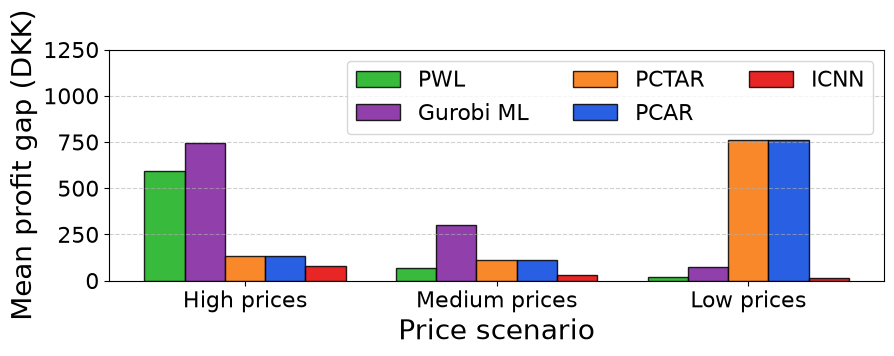

In [22]:
# Grouped bar chart: mean profit gap (DKK) by method within each scenario type
scenario_order_plot = [s for s in scenario_order if s in profit_gap_table["scenario_type"].unique()]

method_order = [m for m in ["PWL", "Gurobi ML", 
                            "PCTAR", "PCAR", 
                            "ICNN"]
                if m in profit_gap_table["methodology"].unique()]
method_colors = {
    "PWL": "xkcd:green",
    "Gurobi ML": "xkcd:purple",
    "PCTAR": "xkcd:orange",
    "PCAR": "xkcd:blue",
    "ICNN": "xkcd:red",
}

fig, ax = plt.subplots(figsize=(10, 3))
n_methods = len(method_order)
x = np.arange(len(scenario_order_plot))
width = 0.8 / max(n_methods, 1)

for j, method in enumerate(method_order):
    means, stds = [], []
    for scn in scenario_order_plot:
        row = profit_gap_table[(profit_gap_table["scenario_type"] == scn) &
                               (profit_gap_table["methodology"] == method)]
        means.append(row["profit_gap_DKK"].values[0] if len(row) else np.nan)
        stds.append(row["profit_gap_DKK_std"].values[0] if len(row) else np.nan)
    ax.bar(x + j * width - 0.4 + width / 2, means, width,
           #yerr = stds, 
           capsize=5, label=method,
           color=method_colors.get(method, None), edgecolor="black", alpha=0.85)

#ax.set_yscale("log")
ax.set_xticks(x)
ax.set_yticks([250 * i for i in range(6)])
ax.set_xticklabels(scenario_order_plot, fontsize=16)
ax.set_ylabel("Mean profit gap (DKK)", fontsize=20)
ax.set_xlabel("Price scenario", fontsize=20)
ax.tick_params(axis="y", labelsize=16)
ax.legend(ncols=3, fontsize=16, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
plt.savefig(os.path.join(images_revised_path, "profit_gap_vs_nlp_bar.pdf"), bbox_inches="tight")
plt.show()

In [23]:
profit_gap_table.to_csv("profit_gap_table.csv")

### Optional: optimality-gap (%) figure

Same grouping but for the (guarded) optimality gap. Note the low-price bars may
be missing/NaN where the NLP optimum is near zero — this is expected and is why
the DKK profit gap is the scale-stable measure; the % gap aids cross-scenario comparison.

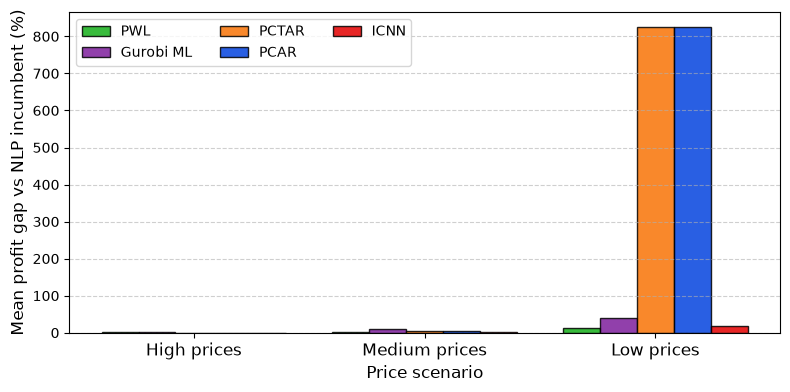

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(scenario_order_plot))
width = 0.8 / max(len(method_order), 1)
for j, method in enumerate(method_order):
    vals = []
    for scn in scenario_order_plot:
        row = profit_gap_table[(profit_gap_table["scenario_type"] == scn) &
                               (profit_gap_table["methodology"] == method)]
        vals.append(row["profit_gap_pct"].values[0] if len(row) else np.nan)
    ax.bar(x + j * width - 0.4 + width / 2, vals, width, label=method,
           color=method_colors.get(method, None), edgecolor="black", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(scenario_order_plot, fontsize="large")
ax.set_ylabel("Mean profit gap vs NLP incumbent (%)", fontsize="large")
ax.set_xlabel("Price scenario", fontsize="large")
ax.tick_params(axis="y", labelsize="medium")
ax.legend(ncols=3, fontsize="medium")
ax.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)

plt.tight_layout()
plt.savefig(os.path.join(images_revised_path, "profit_gap_vs_nlp_bar_pct.pdf"), bbox_inches="tight")
plt.show()

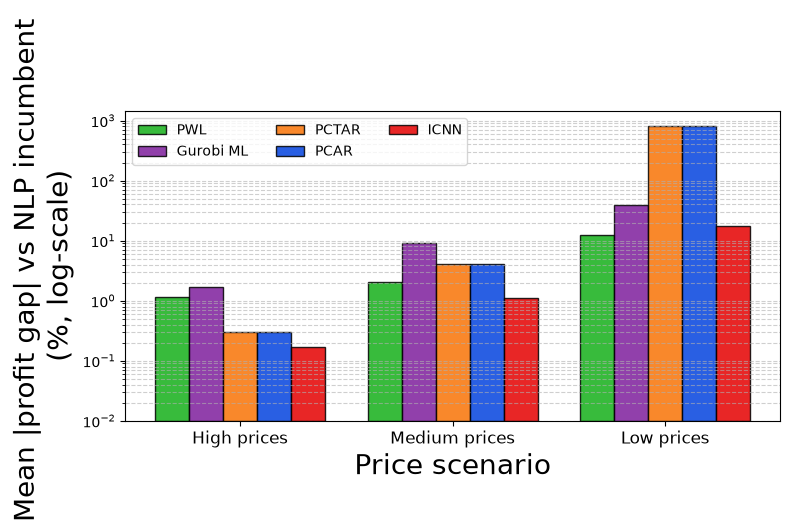

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(scenario_order_plot))
width = 0.8 / max(len(method_order), 1)
floor = 1e-2   # positive baseline for log bars (0.01%); adjust to smallest meaningful gap

for j, method in enumerate(method_order):
    vals = []
    for scn in scenario_order_plot:
        row = profit_gap_table[(profit_gap_table["scenario_type"] == scn) &
                               (profit_gap_table["methodology"] == method)]
        v = row["profit_gap_pct"].values[0] if len(row) else np.nan
        vals.append(v)
    vals = np.array(vals, dtype=float)
    heights = np.clip(np.abs(vals), floor, None)   # |gap| for log scale
    ax.bar(x + j * width - 0.4 + width / 2, heights, width,
           bottom=floor, label=method,
           color=method_colors.get(method, None), edgecolor="black", alpha=0.85)

ax.set_yscale("log")
ax.set_ylim(bottom=floor)
ax.set_xticks(x)
ax.set_xticklabels(scenario_order_plot, fontsize="large")
ax.set_ylabel("Mean |profit gap| vs NLP incumbent \n(%, log-scale)", fontsize=20)
ax.set_xlabel("Price scenario", fontsize=20)
ax.tick_params(axis="y", labelsize="medium")
ax.legend(ncols=3, fontsize="medium")
ax.grid(axis="y", which="both", linestyle="--", alpha=0.6, zorder=0)

plt.tight_layout()
plt.savefig(os.path.join(images_revised_path, "profit_gap_vs_nlp_bar_pct_log.pdf"), bbox_inches="tight")
plt.show()

## Surrogate accuracy (RMSE / mean square error) table

In [26]:
rmse_view = df[["scenario_type", "methodology", "mean_square_error"]].copy()
rmse_view

,scenario_type,methodology,mean_square_error
0,High prices,Gurobi ML,11064.722
1,High prices,ICNN,130.686
2,High prices,NLP,0.000
3,High prices,PCAR,7970.344
4,High prices,PCTAR,7970.344
5,High prices,PWL,2.307
6,Medium prices,Gurobi ML,1641.679
7,Medium prices,ICNN,57.164
8,Medium prices,NLP,0.000
9,Medium prices,PCAR,1695.129


## Solve-check counts (cases not solved within 1% gap)

In [27]:
(10 - summary_tables.groupby(["scenario_type", "methodology"], observed=True)["solve_check"].sum())

scenario_type  methodology
High prices    Gurobi ML       0
               ICNN            0
               NLP             0
               PCAR            0
               PCTAR           0
               PWL             0
Medium prices  Gurobi ML       0
               ICNN            0
               NLP             5
               PCAR            0
               PCTAR           0
               PWL             0
Low prices     Gurobi ML       0
               ICNN            0
               NLP            10
               PCAR            0
               PCTAR           0
               PWL             0
Name: solve_check, dtype: object

## CPU runtime figures

Reproduced from the original notebook with **ICNN 1 removed** and figures saved
to `images_revised/`. Grouping is by methodology.

In [28]:
grouped_df = summary_tables.groupby("methodology")["cpu_time"]

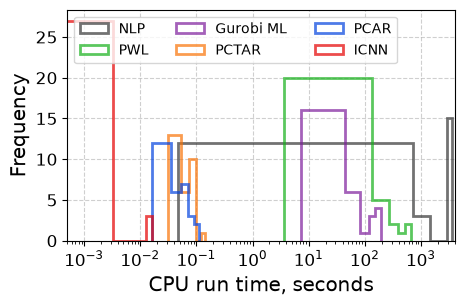

In [29]:
# Step-histogram of CPU runtime (log scale). ICNN 1 dropped; NLP added.
fig, ax = plt.subplots(figsize=(5, 3))
colors = ['xkcd:dark gray', 'xkcd:green', 'xkcd:purple', 'xkcd:orange', 'xkcd:blue', 'xkcd:red']
plot_order = ["NLP", "PWL", "Gurobi ML", "PCTAR", "PCAR", "ICNN"]

for i, name in enumerate(plot_order):
    if name in grouped_df.groups:
        group = grouped_df.get_group(name)
        ax.hist(group, bins=5, alpha=0.7, label=name,
                edgecolor=colors[i % len(colors)], histtype="step", linewidth=2)

ax.set_xlabel('CPU run time, seconds', fontsize="x-large")
ax.set_ylabel('Frequency', fontsize="x-large")
ax.tick_params(axis='x', labelsize="large")
ax.tick_params(axis='y', labelsize="large")
ax.set_xscale('log')
ax.set_xlim([5 * 10**-4, 4000])
ax.legend(ncols=3, fontsize="medium", loc="upper left")
plt.grid(axis='both', linestyle='--', alpha=0.6, zorder=0)
plt.savefig(os.path.join(images_revised_path, "cpu_runtime_histograms.pdf"), bbox_inches="tight")
plt.show()

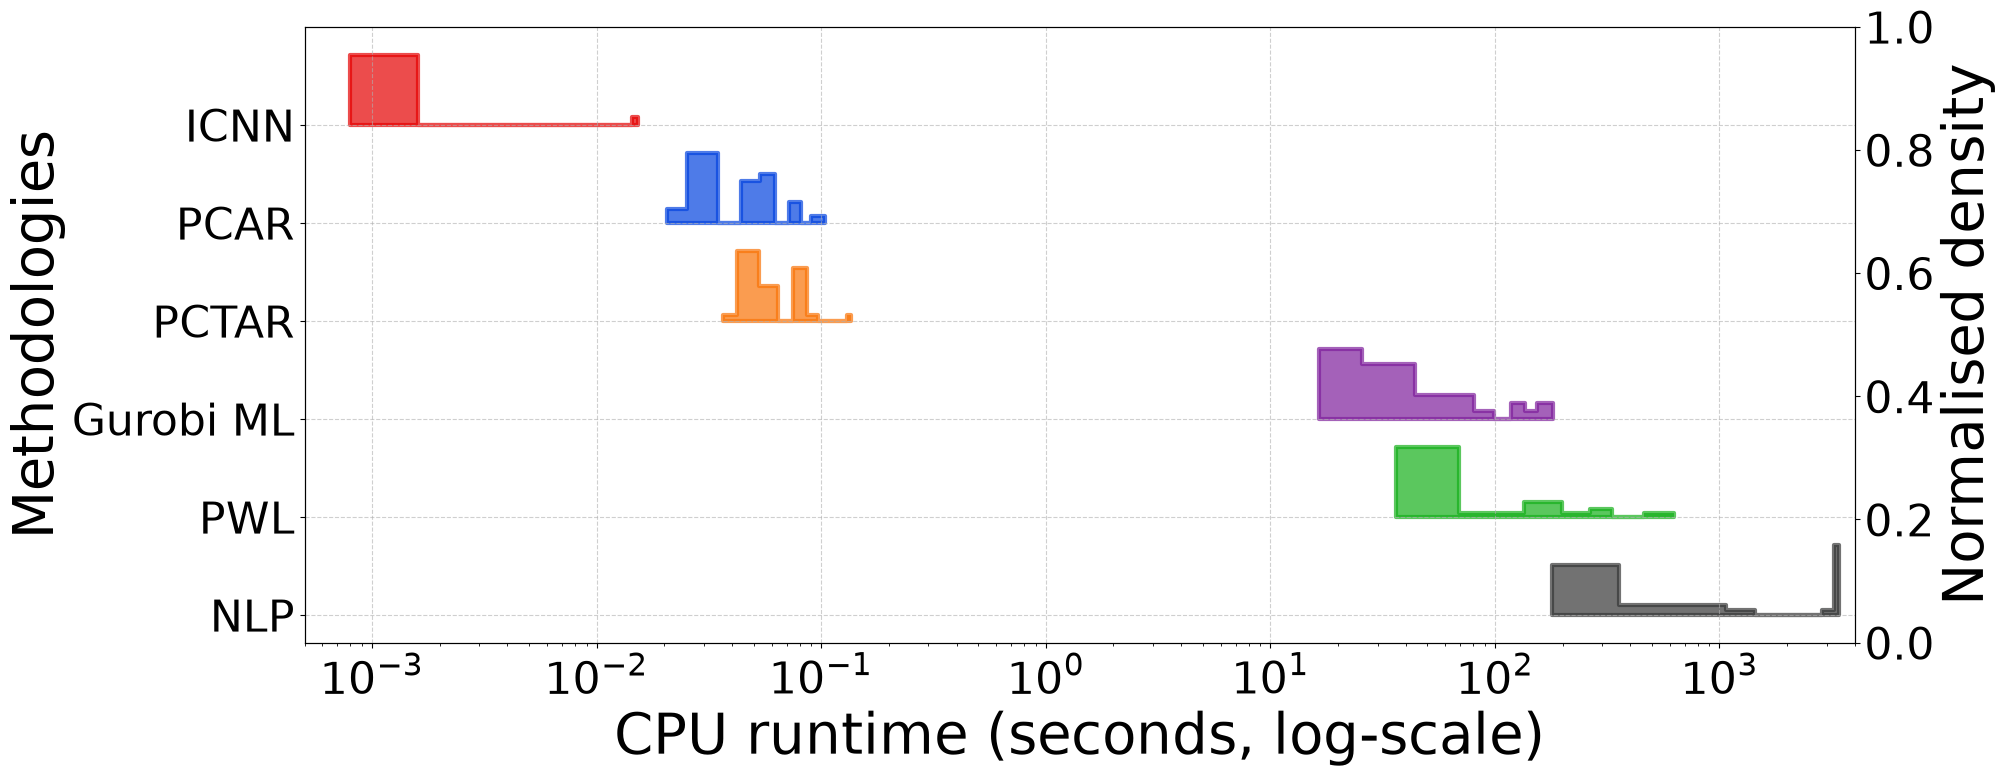

In [30]:
# Ridgeline CPU runtime (normalised density), ICNN 1 removed, FICNN -> ICNN
s = 2   # uniform scale factor: enlarges figure AND fonts together

fig, ax = plt.subplots(figsize=(10 * s, 4 * s))
colors = ['xkcd:dark gray', 'xkcd:green', 'xkcd:purple', 'xkcd:orange', 'xkcd:blue', 'xkcd:red']
plot_order = ["NLP", "PWL", "Gurobi ML", "PCTAR", "PCAR", "ICNN"]
y_spacing = 1.40
max_height = 1.0
for i, name in enumerate(plot_order):
    if name not in grouped_df.groups:
        continue
    group = grouped_df.get_group(name).astype(float).values.flatten()
    density, bins = np.histogram(group, bins=10, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    if density.max() > 0:
        density = density / density.max() * max_height
    baseline = i * y_spacing
    ax.fill_between(bin_centers, baseline, density + baseline, step="mid",
                    color=colors[i % len(colors)], alpha=0.7, linewidth=1.5 * s, label=name)
ax.set_xscale("log")
ax.set_xlabel("CPU runtime (seconds, log-scale)", fontsize=20 * s)
ax.set_ylabel("Methodologies", fontsize=20 * s)
ax.set_yticks([i * y_spacing for i in range(len(plot_order))])
ax.set_xlim([5 * 10**-4, 4000])
ax.set_yticklabels(plot_order, fontsize=16 * s)
ax.tick_params(axis="x", labelsize=16 * s)
ax.grid(axis="both", linestyle="--", alpha=0.6)
ax2 = ax.twinx()
ax2.set_ylim(0, max_height)
ax2.set_ylabel("Normalised density", fontsize=20 * s)
ax2.tick_params(axis="y", labelsize=16 * s)
plt.savefig(os.path.join(images_revised_path, "ridge_plot_histograms_cpu_runtime.pdf"), bbox_inches="tight")
plt.show()

## Notes for the write-up

- **Profit-gap table** (`profit_gap_table_revised.pickle`) gives mean profit gap
  (DKK and %) per (scenario, method) vs the NLP incumbent.
- **NLP is a 1%-target, time-limited incumbent, NOT an optimum.** Do not label it
  "Exact NLP" in the paper. Negative gaps => surrogate matched/exceeded a
  non-converged incumbent, not super-optimality. State this in captions.
- **DKK gap** is scale-stable; the **% gap** is included to compare across scenarios
  whose profit magnitudes differ by orders of magnitude (as requested).
- **Figure vs table**: include the profit-gap table for exact numbers, and the
  `profit_gap_vs_nlp_bar.pdf` (DKK) as the primary visual; the % versions
  (`_pct`, `_pct_log`) support cross-scenario magnitude comparison.
- The NLP did not converge in medium- (2.5% gap, time limit) and low-price cases
  (80% gap, time limit); its objective is a best incumbent (lower bound). Frame the
  NLP results as an intractability demonstration, not a regret-vs-optimum analysis.
- All new figures are in `images_revised/`.